# MRI-ESM2-0 — MLR: FWI vs. 4 Climate Drivers (Thailand)

Loads precomputed cache from `MRI-ESM2-0_FWI_Compute.ipynb` (area-weighted annual means) and performs Multiple Linear Regression analysis (Steps 6–10). Steps 1–2 set up dependencies and configuration.

| Variable | Units (stored) | Notes |
|---|---|---|
| `fwisa` | dimensionless | Annual, area-weighted mean over Thailand (2.5° grid) |
| `tasmax` | K → °C | Monthly → annual via `groupby` |
| `pr` | kg m⁻² s⁻¹ → mm day⁻¹ | Monthly → annual via `groupby` |
| `sfcWind` | m s⁻¹ | Monthly → annual via `groupby` |
| `hurs` | % | Monthly → annual via `groupby` |

> Run `MRI-ESM2-0_FWI_Compute.ipynb` at least once to populate the cache.

## 1  Dependencies

Import `numpy`, `pandas`, `statsmodels`, `scipy`, `matplotlib`, and `pathlib`.

In [3]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import zscore
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2  Configuration

Set `CACHE_DIR` to the directory written by `MRI-ESM2-0_FWI_Compute.ipynb` and define the list of SSP scenarios to include in the panel.

In [5]:
# Scenario keys and display labels (must match what was used when saving cache)
SCENARIOS = [
    "historical", "ssp119", "ssp126", "ssp245",
    "ssp370", "ssp434", "ssp460", "ssp534", "ssp585",
]
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp434":     "SSP4-3.4",
    "ssp460":     "SSP4-6.0",
    "ssp534":     "SSP5-3.4",
    "ssp585":     "SSP5-8.5",
}

CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire/new/src/MRI-ESM2/hurs/computed_means_MRI-ESM2-0")

## 3  Build panel DataFrame from cache

Load per-scenario 1-D DataArrays (already area-weighted annual means) from NetCDF cache and assemble them into a tidy `panel_df_th` DataFrame with columns `FWI`, `tasmax`, `pr`, `hurs`, `sfcWind`, and `scenario` — ready for MLR.

In [7]:
def _load(var_name):
    return {
        s: xr.open_dataarray(CACHE_DIR / f"{var_name}_{s}.nc").load()
        for s in SCENARIOS
        if (CACHE_DIR / f"{var_name}_{s}.nc").exists()
    }

fwi_means     = _load("fwi")
tasmax_means  = _load("tasmax")
pr_means      = _load("pr")
sfcWind_means = _load("sfcWind")
hurs_means    = _load("hurs")

rows = []
for scen in SCENARIOS:
    fwi_da = fwi_means[scen]
    t      = fwi_da["year"]
    rows.append(pd.DataFrame({
        "time"    : t.values.astype(int),
        "FWI"     : fwi_da.values,
        "tasmax"  : (tasmax_means[scen].sel(year=t, method="nearest") - 273.15  ).values,
        "pr"      : (pr_means[scen].sel(   year=t, method="nearest") * 86_400.0).values,
        "sfcWind" : sfcWind_means[scen].sel(year=t, method="nearest").values,
        "hurs"    : hurs_means[scen].sel(   year=t, method="nearest").values,
        "scenario": SCENARIO_LABELS[scen],
    }))

panel_df_th = pd.concat(rows, ignore_index=True)
for c in ["FWI", "tasmax", "pr", "hurs", "sfcWind"]:
    panel_df_th[c] = pd.to_numeric(panel_df_th[c], errors="coerce")
panel_df_th.replace([np.inf, -np.inf], np.nan, inplace=True)
panel_df_th.dropna(subset=["FWI", "tasmax", "pr", "hurs", "sfcWind"], inplace=True)
panel_df_th["time"]     = panel_df_th["time"].astype(int)
panel_df_th["scenario"] = panel_df_th["scenario"].astype(object)

print(panel_df_th.head())
print()
print("Rows per scenario:")
print(panel_df_th.groupby("scenario").size())

   time        FWI     tasmax        pr   sfcWind       hurs    scenario
0  1850  16.750235  28.563620  5.553327  3.123170  78.760792  Historical
1  1851  18.509382  28.646525  5.696610  3.051434  78.954632  Historical
2  1852  18.850577  28.575319  5.536260  3.135036  78.321603  Historical
3  1853  19.509428  28.601957  5.508522  3.106360  77.920828  Historical
4  1854  19.309488  28.711414  5.414630  3.086019  77.929367  Historical

Rows per scenario:
scenario
Historical    165
SSP1-1.9       86
SSP1-2.6       86
SSP2-4.5       86
SSP3-7.0       86
SSP4-3.4       86
SSP4-6.0       86
SSP5-3.4       61
SSP5-8.5       86
dtype: int64


## 4  OLS Multiple Linear Regression

Fit `FWI ~ tasmax + pr + hurs + sfcWind [+ C(scenario)]` using OLS with HC1 heteroskedasticity-robust standard errors (`statsmodels.formula.api.ols`). Scenario fixed effects are included when ≥ 2 scenarios are pooled.

In [9]:
assert 'panel_df_th' in globals() and len(panel_df_th) > 0, \
    "panel_df_th is missing or empty — run Section 6 first."

use_fe  = panel_df_th['scenario'].nunique() >= 2
formula = 'FWI ~ tasmax + pr + hurs + sfcWind' + (' + C(scenario)' if use_fe else '')
print('Formula:', formula)

mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print(mlr_model.summary())

Formula: FWI ~ tasmax + pr + hurs + sfcWind + C(scenario)
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                     981.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:51:03   Log-Likelihood:                -1179.3
No. Observations:                 828   AIC:                             2385.
Df Residuals:                     815   BIC:                             2446.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

## 5  Standardised (Beta) Coefficients

Z-score all continuous predictors so that coefficients are directly comparable in units of standard deviations. Report beta coefficients for the pooled model and per-scenario models separately, together with R².

In [11]:
to_z   = ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']
df_std = panel_df_th.copy()
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')

print('=== Standardised (beta) coefficients ===')
print(mlr_model_beta.params[['tasmax', 'pr', 'hurs', 'sfcWind']].round(3))
print()
print('Positive beta => variable increases as FWI increases')
print('Negative beta => inverse relationship with FWI')
print()
print(f'R² (all SSP pooled) = {mlr_model_beta.rsquared:.3f}')

ci = mlr_model.conf_int()
coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    'z'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
    'CI_low' : ci[0],
    'CI_high': ci[1],
})
print()
print('=== Coefficients table (HC1) ===')
print(coef_table.round(3))

=== Standardised (beta) coefficients ===
tasmax     0.155
pr         0.113
hurs      -0.908
sfcWind   -0.005
dtype: float64

Positive beta => variable increases as FWI increases
Negative beta => inverse relationship with FWI

R² (all SSP pooled) = 0.900

=== Coefficients table (HC1) ===
                            coef  HC1_se       z  pvalue   CI_low  CI_high
Intercept                159.654   9.544  16.728   0.000  140.948  178.360
C(scenario)[T.SSP1-1.9]   -1.164   0.113 -10.281   0.000   -1.386   -0.942
C(scenario)[T.SSP1-2.6]   -0.975   0.127  -7.661   0.000   -1.225   -0.726
C(scenario)[T.SSP2-4.5]   -0.750   0.130  -5.767   0.000   -1.004   -0.495
C(scenario)[T.SSP3-7.0]    0.016   0.159   0.099   0.921   -0.297    0.328
C(scenario)[T.SSP4-3.4]   -0.773   0.203  -3.813   0.000   -1.170   -0.376
C(scenario)[T.SSP4-6.0]   -0.022   0.208  -0.107   0.915   -0.430    0.385
C(scenario)[T.SSP5-3.4]   -0.768   0.212  -3.615   0.000   -1.184   -0.352
C(scenario)[T.SSP5-8.5]   -0.450   0.

In [12]:
# ── Beta coefficients per scenario ───────────────────────────────────────────
drivers        = ['tasmax', 'pr', 'hurs', 'sfcWind']
formula_single = 'FWI ~ tasmax + pr + hurs + sfcWind'

rows_per_scen = []
for scen_label in panel_df_th['scenario'].unique():
    df_scen = panel_df_th[panel_df_th['scenario'] == scen_label].copy()
    if len(df_scen) < 5:
        continue
    df_z = df_scen.copy()
    df_z[['FWI'] + drivers] = df_z[['FWI'] + drivers].apply(zscore)
    model = smf.ols(formula_single, data=df_z).fit(cov_type='HC1')
    row = {'Scenario': scen_label}
    row.update(model.params[drivers].round(3).to_dict())
    row['R²'] = round(model.rsquared, 3)
    rows_per_scen.append(row)

df_beta_per_scen = pd.DataFrame(rows_per_scen).set_index('Scenario')
print('=== Standardised Beta Coefficients per Scenario ===')
print(df_beta_per_scen.to_string())

=== Standardised Beta Coefficients per Scenario ===
            tasmax     pr   hurs  sfcWind     R²
Scenario                                        
Historical   0.121  0.221 -1.035    0.014  0.897
SSP1-1.9    -0.106  0.157 -1.089   -0.098  0.846
SSP1-2.6    -0.153  0.215 -1.037   -0.116  0.733
SSP2-4.5    -0.097  0.277 -1.044    0.062  0.896
SSP3-7.0     0.225  0.189 -0.886   -0.027  0.930
SSP4-3.4    -0.038  0.042 -1.022   -0.083  0.839
SSP4-6.0     0.089  0.172 -0.924    0.019  0.864
SSP5-3.4     0.096  0.169 -0.904    0.085  0.822
SSP5-8.5     0.122  0.115 -0.898   -0.022  0.966


## 6  Diagnostic Plots

Visual checks for model fit: residuals vs fitted, Q-Q plot, and scale-location plot.

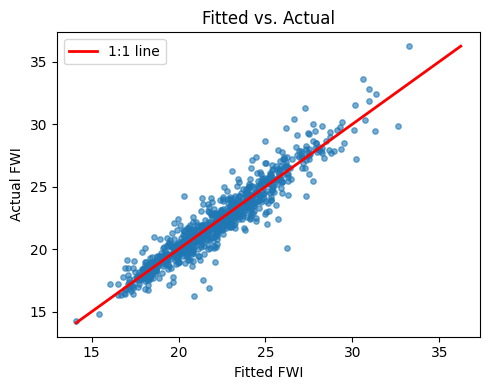

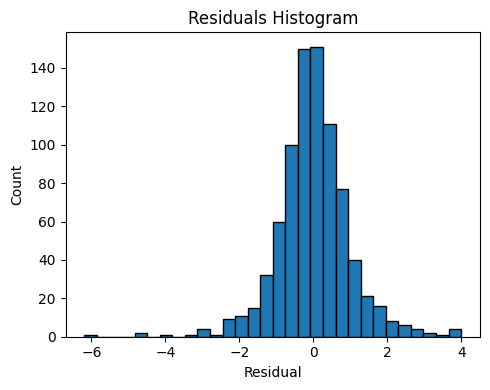

In [14]:
y     = panel_df_th['FWI'].values
yhat  = mlr_model.fittedvalues.values
resid = mlr_model.resid.values

plt.figure(figsize=(5, 4))
plt.scatter(yhat, y, s=15, alpha=0.6)
mn, mx = np.min([y, yhat]), np.max([y, yhat])
plt.plot([mn, mx], [mn, mx], lw=2, color='red', label='1:1 line')
plt.xlabel('Fitted FWI')
plt.ylabel('Actual FWI')
plt.title('Fitted vs. Actual')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(resid, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residuals Histogram')
plt.tight_layout()
plt.show()

## 7  Variance Inflation Factors (VIF)

Compute VIF for each predictor using `statsmodels.stats.outliers_influence.variance_inflation_factor`. VIF > 10 indicates problematic multicollinearity. Report VIF for the pooled model and per-scenario models separately.

In [16]:
cols           = ['FWI', 'tasmax', 'pr', 'hurs', 'sfcWind']
panel_df_clean = panel_df_th.dropna(subset=cols).copy()

X = panel_df_clean[['tasmax', 'pr', 'hurs', 'sfcWind']]
X = add_constant(X)

vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF'     : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print(vif_data.round(3))

  Variable        VIF
0    const  30677.356
1   tasmax      3.312
2       pr      1.694
3     hurs      4.902
4  sfcWind      1.592


In [17]:
# ── VIF per scenario ─────────────────────────────────────────────────────────
drivers_vif = ['tasmax', 'pr', 'hurs', 'sfcWind']

print('=== VIF per Scenario ===')
for scen_label in panel_df_th['scenario'].unique():
    df_scen = panel_df_th[panel_df_th['scenario'] == scen_label].dropna(subset=drivers_vif).copy()
    if len(df_scen) < 5:
        continue
    X = add_constant(df_scen[drivers_vif])
    vif = pd.DataFrame({
        'Variable': drivers_vif,
        'VIF'     : [variance_inflation_factor(X.values, i+1) for i in range(len(drivers_vif))],
    })
    print(f'\n  {scen_label}')
    print(vif.to_string(index=False))

=== VIF per Scenario ===

  Historical
Variable      VIF
  tasmax 2.293276
      pr 4.091859
    hurs 5.957791
 sfcWind 1.154181

  SSP1-1.9
Variable      VIF
  tasmax 4.464790
      pr 2.197582
    hurs 5.748751
 sfcWind 1.257361

  SSP1-2.6
Variable      VIF
  tasmax 3.343606
      pr 1.876304
    hurs 3.556202
 sfcWind 1.247934

  SSP2-4.5
Variable      VIF
  tasmax 5.933346
      pr 2.165089
    hurs 7.158364
 sfcWind 1.658095

  SSP3-7.0
Variable      VIF
  tasmax 5.324484
      pr 2.141789
    hurs 7.986017
 sfcWind 2.435406

  SSP4-3.4
Variable      VIF
  tasmax 4.375925
      pr 2.701768
    hurs 7.928731
 sfcWind 1.646015

  SSP4-6.0
Variable      VIF
  tasmax 2.514366
      pr 1.837516
    hurs 3.283528
 sfcWind 1.289034

  SSP5-3.4
Variable      VIF
  tasmax 2.779591
      pr 2.073211
    hurs 4.391769
 sfcWind 1.471888

  SSP5-8.5
Variable      VIF
  tasmax 5.284850
      pr 1.673720
    hurs 5.023966
 sfcWind 2.745736
